# EDA 

In [13]:
import pandas as pd
import numpy as np 


In [17]:
train_csv_path= "../../data/amia-public-challenge-2026/train.csv"
df= pd.read_csv(train_csv_path)
df.head()

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,bM8C97htulC9fHKIDurJHquCXr1KZuug,No finding,14,R5,NaN,NaN,NaN,NaN
1,0FDQVdLgDKI1sRnPL94LzVh9EvXDVM9m,Aortic enlargement,0,R10,1148.0,503.0,1466.0,823.0
2,Dwk2TnGJFaMhyi3OfCrhdZG9ppGglC5w,Consolidation,4,R8,264.0,732.0,550.0,1119.0
3,vqw6mWifHgCf8jmTotrMAS3qCk5eJuc4,No finding,14,R13,NaN,NaN,NaN,NaN
4,EzfCkMwi4E5bAtZZo4brqt9dNbm7sF9z,No finding,14,R5,NaN,NaN,NaN,NaN


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45925 entries, 0 to 45924
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image_id    45925 non-null  str    
 1   class_name  45925 non-null  str    
 2   class_id    45925 non-null  int64  
 3   rad_id      45925 non-null  str    
 4   x_min       30400 non-null  float64
 5   y_min       30400 non-null  float64
 6   x_max       30400 non-null  float64
 7   y_max       30400 non-null  float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.8 MB


In [19]:
df.nunique()

image_id      8573
class_name      15
class_id        15
rad_id          17
x_min         2504
y_min         2549
x_max         2627
y_max         2690
dtype: int64

In [20]:
df['class_name'].value_counts(dropna=False)

class_name
No finding            15525
Aortic enlargement     5481
Pleural thickening     4308
Pulmonary fibrosis     4097
Cardiomegaly           4046
Nodule/Mass            2324
Pleural effusion       2190
Lung Opacity           2188
Other lesion           1945
Infiltration           1097
ILD                     904
Calcification           851
Consolidation           519
Atelectasis             255
Pneumothorax            195
Name: count, dtype: int64

In [21]:
df['class_id'].value_counts(dropna=False)

class_id
14    15525
0      5481
11     4308
13     4097
3      4046
8      2324
10     2190
7      2188
9      1945
6      1097
5       904
2       851
4       519
1       255
12      195
Name: count, dtype: int64

In [22]:
null_df=(df['class_id']!= 14) & (df['x_min'].isnull() | df['y_min'].isnull() | df['x_max'].isnull() | df['y_max'].isnull())
null_df.value_counts()

False    45925
Name: count, dtype: int64

In [23]:
df.groupby('image_id')['class_id'].nunique().value_counts()

class_id
1     5344
2      788
3      763
4      647
5      476
6      286
7      172
8       71
9       22
10       4
Name: count, dtype: int64

8573 unique images across 15 classes (0 to 14 , 14 being no finding)
No missing labels. Every entry has a class assigned. And every row that has a disease assigned has valid bounding box coordinates. 
Some images have upto 10 diseases assigned (i.e to say some images have multiple classes assigned). 

In [25]:
import os
train_image_path= "../../data/amia-public-challenge-2026/train/train"
files = [f.replace('.png', '') for f in os.listdir(train_image_path) if os.path.isfile(os.path.join(train_image_path, f))]
files= set(files)
images= set(df['image_id'].unique())
missing_images= images - files
print(f"Missing images: {missing_images}")


Missing images: set()


All images are present. 

In [26]:
df['rad_id'].nunique()

17

17 Radiologists in total. But how were they assigned? multiple radiologists evaluated multiple images? let's look at one image to see. 

In [27]:
df.loc[df['image_id'] == 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx']

,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
8,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Nodule/Mass,8,R8,1594.0,1222.0,1743.0,1381.0
5934,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Aortic enlargement,0,R10,1200.0,545.0,1480.0,848.0
10285,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Cardiomegaly,3,R8,846.0,1327.0,1829.0,1769.0
13943,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Cardiomegaly,3,R9,859.0,1340.0,1833.0,1716.0
19999,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Aortic enlargement,0,R8,1209.0,537.0,1482.0,932.0
20575,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Infiltration,6,R9,494.0,1148.0,915.0,1687.0
21566,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Other lesion,9,R9,494.0,1148.0,915.0,1687.0
25307,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Nodule/Mass,8,R9,1601.0,1234.0,1746.0,1368.0
40165,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Nodule/Mass,8,R10,1600.0,1242.0,1747.0,1377.0
41641,w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx,Cardiomegaly,3,R10,851.0,1417.0,1856.0,1759.0


In [28]:
list_no_radiologists_for_an_image=df.groupby('image_id')['rad_id'].nunique()
print("No. of radiologists|| No. of images")
print(list_no_radiologists_for_an_image.value_counts())

No. of radiologists|| No. of images
rad_id
3    8573
Name: count, dtype: int64


Every image was evaluated by 3 radiologists. So there are three possible distinct classes & boundary boxes asssigned to an image. 

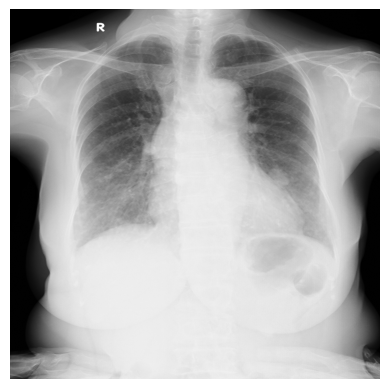

In [29]:
import matplotlib.pyplot as plt
sample_image_path= os.path.join(train_image_path, 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx.png')  
# Load the image
img = plt.imread(sample_image_path)

# Display the image
plt.imshow(img, cmap='gray')
plt.axis('off')  
plt.show()   

In [30]:
img.shape

(1024, 1024)

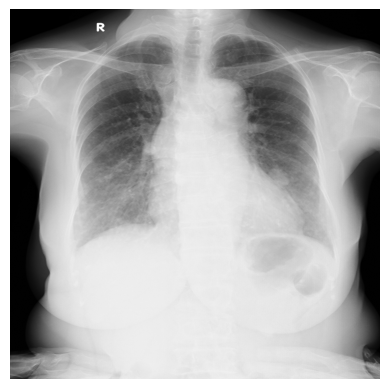

In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
fig, ax = plt.subplots()
image_path= os.path.join(train_image_path, 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx.png')  
# Load the image
img = plt.imread(image_path)

# Display the image
ax.imshow(img, cmap='gray')
ax.axis('off')  

rows_of_image =df.loc[df['image_id']== 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx'] 
#print(rows_of_image)

for index, row in rows_of_image.iterrows():
    rect= Rectangle((row['x_min'], row['y_min']), row['x_max']- row['x_min'], row['y_max']- row['y_min'], 
                    fill= False, edgecolor='red', linewidth=2, alpha=0.5)
    ax.add_patch(rect)

plt.show()


The boundary boxes aren't being drawn. As mentioned in the discussions, boundary box coordinates are according to actual image size as per in img_size.csv and not in the 1024x1024 that we have the images in. So resizing the 

In [32]:
image_size_df= pd.read_csv("../../data/amia-public-challenge-2026/img_size.csv")
image_size= image_size_df.loc[image_size_df['image_id'] == 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx']
x, y= image_size['dim1'], image_size['dim0']
original_x, original_y= x.values[0], y.values[0]
print(f"Image dimensions: { original_x} x {original_y}")

Image dimensions: 2304 x 2880


In [33]:
x_scale= 1024/original_x
y_scale= 1024/original_y
print(f"X scale factor: {x_scale}") 
print(f"Y scale factor: {y_scale}")

X scale factor: 0.4444444444444444
Y scale factor: 0.35555555555555557


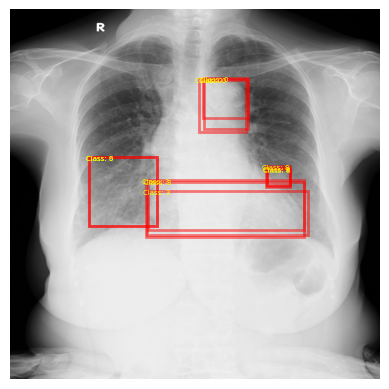

In [34]:

fig, ax = plt.subplots()
image_path= os.path.join(train_image_path, 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx.png')  
# Load the image
img = plt.imread(image_path)

# Display the image
ax.imshow(img, cmap='gray')
ax.axis('off')  

rows_of_image =df.loc[df['image_id']== 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx'] 
#print(rows_of_image)

for index, row in rows_of_image.iterrows():
    rect= Rectangle((row['x_min']*x_scale, row['y_min']*y_scale), (row['x_max']- row['x_min'])*x_scale, (row['y_max']- row['y_min'])*y_scale, 
                    fill= False, edgecolor='red', linewidth=2, alpha=0.5)
    ax.add_patch(rect)
    ax.text(row['x_min']*x_scale-10, row['y_min']*y_scale-5, f"Class: {row['class_id']}", color='yellow', fontsize=5, verticalalignment='top')

plt.show()

Since 3 radiologists have marked this image, it looks cluttered, let's make a separate plot for each radiologist. 

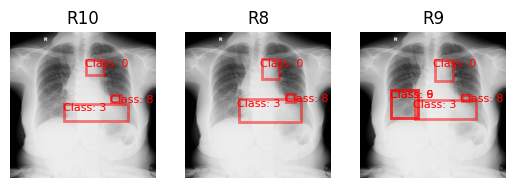

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=3)
image_path= os.path.join(train_image_path, 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx.png')  
# Load the image
img = plt.imread(image_path)

rows_of_image =df.loc[df['image_id']== 'w6fPyFCOHnKXcXhD5m1XxEbfTa5nWDwx'] 

for rowsofgroups, individual in zip(rows_of_image.groupby('rad_id'), ax):
    individual.imshow(img, cmap='gray')
    individual.axis('off')
    rad_id, group= rowsofgroups
    for index, row in group.iterrows():
        rect= Rectangle((row['x_min']*x_scale, row['y_min']*y_scale), (row['x_max']- row['x_min'])*x_scale, (row['y_max']- row['y_min'])*y_scale, 
                                fill= False, edgecolor='red', linewidth=2, alpha=0.5)
        individual.add_patch(rect)
        individual.text(row['x_min']*x_scale-10, row['y_min']*y_scale-5, f"Class: {row['class_id']}", color='red', fontsize=8, verticalalignment='top')
        individual.set_title(rad_id)

plt.show()

# Data Pipeline


In [36]:
RANDOM_SEED= 42

In [37]:
from sklearn.model_selection import train_test_split

image_ids = df["image_id"].unique()

train_ids, val_ids = train_test_split(
    image_ids,
    test_size=0.2,
    random_state=RANDOM_SEED
)
print(f"Number of training images: {len(train_ids)}")
print(f"Number of validation images: {len(val_ids)}")
print(train_ids[:5])
print(val_ids[:5])

Number of training images: 6858
Number of validation images: 1715
<StringArray>
['5qbn9thLMz4l46F2Y5k6b3nBUpSCn9xt', 'sefNkeRDSZBk2oghaVv07NnPJus9ZWeG',
 'znF2Rr31I7thNZLE4YkObYjvd1oqxvxz', 'bAQKhnFlUXjlNfgQDgFYnlVoqvC3RQa7',
 'bopx3pPWQVZxGmzua8PjQUFYmY99IM9G']
Length: 5, dtype: str
<StringArray>
['XB6mSLXwPXIHP5wh78fkBOxZ2VTxrSDI', '6aDnLkmTGigODVSdvMgOiYZZLE72JpDB',
 'L86Zwi0EzNTbM1qqpH0wfx9PbV2qtYsh', '7LNUT8q0vq54ediORASgQV2AJuzMelgr',
 'kJcgW9RU7X7aRAIkmVWlb2Q9S3dyemUL']
Length: 5, dtype: str


In [39]:
import torch
import torchvision
from torchvision import transforms as torchtrans 
import cv2
import os 
import pandas as pd 
import numpy as np
# defining the files directory and testing directory
train_dir = '../../data/amia-public-challenge-2026/train/train'
test_dir = '../../data/amia-public-challenge-2026/test/test'
image_size_df= pd.read_csv("../../data/amia-public-challenge-2026/img_size.csv")

train_csv_path= "../../data/amia-public-challenge-2026/train.csv"
df= pd.read_csv(train_csv_path)


class ChestX_RAYDataset(torch.utils.data.Dataset):

    def __init__(self, files_dir, image_ids, transforms=None):
        self.transforms = transforms
        self.files_dir = files_dir

        self.imgs = image_ids#[image for image in os.listdir(self.files_dir)if image[-4:]=='.png']
        self.df = df
        self.image_size_df = image_size_df

    def __getitem__(self, idx):

        img_name = self.imgs[idx]
        #image_path = os.path.join(self.files_dir, img_name)

        # reading the images and converting them to correct color and format
        image_path = os.path.join(self.files_dir,img_name + ".png")
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img_res= (torch.from_numpy(img_rgb).permute(2,0,1).float())/255.0  #scaling, permute rearranges dimensions cz opencv reads in HWC format but pytorch expects CHW format 
        
        boxes = []
        labels = []
        
        # box coordinates for files are extracted and corrected for image size given
        image_size= self.image_size_df.loc[self.image_size_df['image_id'] == img_name]
        x, y= image_size['dim1'], image_size['dim0']
        original_x, original_y= x.values[0], y.values[0]
        x_scale= 1024/original_x
        y_scale= 1024/original_y
        for instance in self.df.loc[self.df['image_id'] == img_name].itertuples():
            if instance.class_id == 14: 
                continue
            labels.append(instance.class_id + 1) #Faster R-CNN reserves 0 = background
            # bounding box
            xmin = instance.x_min
            xmax = instance.x_max
            
            ymin = instance.y_min
            ymax = instance.y_max

            xmin_corr = xmin*x_scale
            xmax_corr = xmax*x_scale
            ymin_corr = ymin*y_scale
            ymax_corr = ymax*y_scale
            
            boxes.append([xmin_corr, ymin_corr, xmax_corr, ymax_corr])
        
        # convert boxes into a torch.Tensor
        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # getting the areas of the boxes
        #area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        # suppose all instances are not crowd
        #iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)


        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        #target["area"] = area
        #target["iscrowd"] = iscrowd
        # image_id
        image_id = torch.tensor([idx])
        target["image_id"] = image_id
        target["image_name"] = img_name


        if self.transforms:
            
            sample = self.transforms(image = img_res,
                                     bboxes = target['boxes'],
                                     labels = labels)
            
            img_res = sample['image']
            target['boxes'] = torch.Tensor(sample['bboxes'])
            
            
            
        return img_res, target

    def __len__(self):
        return len(self.imgs)


# check dataset
train_dataset = ChestX_RAYDataset(train_dir, train_ids)

val_dataset = ChestX_RAYDataset(train_dir, val_ids)
print('length of training dataset = ', len(train_dataset), '\n')
print('length of validation dataset = ', len(val_dataset), '\n')

# getting the image and target for a test index.  Feel free to change the index.
img, target = train_dataset[81]
val_img, val_target = val_dataset[4]

print(img.shape)
print(target["boxes"].shape)
print(target["labels"])

print("val dataset")
print(val_img.shape)
print(val_target["boxes"].shape)
print(val_target["labels"])

length of training dataset =  6858 

length of validation dataset =  1715 

torch.Size([3, 1024, 1024])
torch.Size([5, 4])
tensor([4, 4, 1, 1, 4])
val dataset
torch.Size([3, 1024, 1024])
torch.Size([7, 4])
tensor([ 4,  4,  1,  1,  1, 12, 12])


In [40]:
val_dataset[4]

(tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.2431, 0.0000, 0.0078],
          [0.0000, 0.0000, 0.0000,  ..., 0.3647, 0.3686, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0510, 0.4863, 0.0196],
          ...,
          [0.7255, 0.7216, 0.7176,  ..., 0.6588, 0.6588, 0.6510],
          [0.6824, 0.7059, 0.7255,  ..., 0.6549, 0.6588, 0.6471],
          [0.5059, 0.6275, 0.7373,  ..., 0.6588, 0.6431, 0.6510]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 0.2431, 0.0000, 0.0078],
          [0.0000, 0.0000, 0.0000,  ..., 0.3647, 0.3686, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0510, 0.4863, 0.0196],
          ...,
          [0.7255, 0.7216, 0.7176,  ..., 0.6588, 0.6588, 0.6510],
          [0.6824, 0.7059, 0.7255,  ..., 0.6549, 0.6588, 0.6471],
          [0.5059, 0.6275, 0.7373,  ..., 0.6588, 0.6431, 0.6510]],
 
         [[0.0000, 0.0000, 0.0000,  ..., 0.2431, 0.0000, 0.0078],
          [0.0000, 0.0000, 0.0000,  ..., 0.3647, 0.3686, 0.0000],
          [0.0000, 0.0000, 0.0000,  ...,

In [41]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [42]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)